In [27]:
import pandas as pd
import numpy as np
import tensorflow as tf
import warnings
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.layers import Dense, Dropout, Input
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, precision_recall_fscore_support, classification_report
from transformers import BertTokenizer, TFBertModel
from scipy.io import arff
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, classification_report

In [29]:
# Filtering out FutureWarnings
# Does not change effectiveness of code
# warnings.filterwarnings("ignore", category=FutureWarning)

### Data Description (D4)
- **Files:** target_train/test, shadow_train/test (xlsx or npy embeddings).
- **Labels:** binary (1 = match/member, 0 = non-match/non-member).
- **Embeddings:** BERT-based vectors (dim=768); pairs are (x1, x2).
- **Pairwise features (for head):** L2, cosine, mean |Δ|, mean Hadamard, mean L1, mean squared diff.
- **Splits:** target train/test; shadow train/test for attack construction.


In [32]:
# ==========================
# Step 1: Load data
# ===========================


train_df = pd.read_csv("Datasets/target_train.csv")
test_df = pd.read_csv("Datasets/target_test.csv")
shadow_train_df = pd.read_csv("Datasets/shadow_train.csv")
shadow_test_df = pd.read_csv("Datasets/shadow_test.csv")


In [33]:
print(train_df.head())

        uid1                                              text1       uid2  \
0  6488772-1  A 38-year-old man presented to our office afte...  7383003-1   
1  6069825-1  A 54-year-old male, with alcohol-related liver...  6069825-2   
2  2740309-1  A 32-year-old man (white, 75 kg, 182 cm and no...  8225499-1   
3  1283745-1  A 59-year-old man was admitted to Coronary Car...  7093274-2   
4  6062634-1  A thirty-two-year-old female patient from Mexi...  8245233-2   

                                               text2  label  
0  A 21 year-old man with an established diagnosi...      0  
1  A 47-year-old male, with alcohol-related liver...      1  
2  A 19-year-old male patient presented with high...      0  
3  A 17-year-old boy was involved in a high-impac...      0  
4  A 49-year-old female with a history of nonalco...      0  


In [10]:
import hashlib, os, pathlib

def file_hash(path):
    path = str(path)
    if not os.path.exists(path):
        return "MISSING"
    h = hashlib.md5()
    with open(path, "rb") as f:
        for chunk in iter(lambda: f.read(1<<20), b""):
            h.update(chunk)
    return h.hexdigest()[:8]

#  Update file names & extensions here
maybe_files = [
    "Datasets/target_train.csv",
    "Datasets/target_test.csv",
    "Datasets/shadow_train.csv",
    "Datasets/shadow_test.csv",
    "requirements.txt"  # keep this for environment hash
]

print("=== File Hashes (MD5, 8 chars) ===")
for p in maybe_files:
    print(f"{p:28s} -> {file_hash(p)}")



=== File Hashes (MD5, 8 chars) ===
Datasets/target_train.csv    -> 1076ea0e
Datasets/target_test.csv     -> 82e563cc
Datasets/shadow_train.csv    -> 44dcab1b
Datasets/shadow_test.csv     -> fbf8579f
requirements.txt             -> ba617e91


In [11]:
# For the later experiments load the embeddings using following code
from pathlib import Path

# Point to your Datasets/Embeddings folder
DATA_DIR = Path("Datasets")
EMB_DIR  = DATA_DIR / "Embeddings"

# ---- Target embeddings ----
x1_train = np.load(EMB_DIR / "x1_target_train.npy")
x2_train = np.load(EMB_DIR / "x2_target_train.npy")
y_train  = np.load(EMB_DIR / "y_target_train.npy")
x1_test  = np.load(EMB_DIR / "x1_target_test.npy")
x2_test  = np.load(EMB_DIR / "x2_target_test.npy")
y_test   = np.load(EMB_DIR / "y_target_test.npy")

# ---- Shadow embeddings (for shadow models / attack training) ----
x1_shadow_train = np.load(EMB_DIR / "x1_shadow_train.npy")
x2_shadow_train = np.load(EMB_DIR / "x2_shadow_train.npy")
y_shadow_train  = np.load(EMB_DIR / "y_shadow_train.npy")
x1_shadow_test  = np.load(EMB_DIR / "x1_shadow_test.npy")
x2_shadow_test  = np.load(EMB_DIR / "x2_shadow_test.npy")
y_shadow_test   = np.load(EMB_DIR / "y_shadow_test.npy")




In [14]:
def chk(name, arr):
    print(f"{name:18s} shape={getattr(arr,'shape',None)}  "
          f"nan?={np.isnan(arr).any() if hasattr(arr,'dtype') and np.issubdtype(arr.dtype, np.number) else 'n/a'}")

for n,a in [
    ("x1_train", x1_train), ("x2_train", x2_train), ("y_train", y_train),
    ("x1_test", x1_test), ("x2_test", x2_test), ("y_test", y_test),
    ("x1_shadow_train", x1_shadow_train), ("x2_shadow_train", x2_shadow_train), ("y_shadow_train", y_shadow_train),
    ("x1_shadow_test", x1_shadow_test), ("x2_shadow_test", x2_shadow_test), ("y_shadow_test", y_shadow_test),
]:
    chk(n,a)

x1_train           shape=(32000, 768)  nan?=False
x2_train           shape=(32000, 768)  nan?=False
y_train            shape=(32000,)  nan?=False
x1_test            shape=(8000, 768)  nan?=False
x2_test            shape=(8000, 768)  nan?=False
y_test             shape=(8000,)  nan?=False
x1_shadow_train    shape=(32000, 768)  nan?=False
x2_shadow_train    shape=(32000, 768)  nan?=False
y_shadow_train     shape=(32000,)  nan?=False
x1_shadow_test     shape=(8000, 768)  nan?=False
x2_shadow_test     shape=(8000, 768)  nan?=False
y_shadow_test      shape=(8000,)  nan?=False


In [16]:
# ====================================
# Step 3: Build Siamese Autoencoder
# ====================================
from tensorflow.keras import layers, regularizers, Model, Input


def build_siamese_autoencoder(embedding_dim):
    encoder_input = Input(shape=(embedding_dim,))
    x = layers.Dense(50, activity_regularizer=regularizers.l1(0.01))(encoder_input)
    x = layers.LeakyReLU(negative_slope=0.01)(x)
    encoder_output = layers.Dense(embedding_dim)(x)  # Consider linear output
    encoder = Model(encoder_input, encoder_output)

    decoder_input = Input(shape=(embedding_dim,))
    decoder_output = layers.Dense(embedding_dim, activation='sigmoid')(decoder_input)
    decoder = Model(decoder_input, decoder_output)

    input1 = Input(shape=(embedding_dim,))
    input2 = Input(shape=(embedding_dim,))
    encoded1 = encoder(input1)
    encoded2 = encoder(input2)
    recon1 = decoder(encoded1)
    recon2 = decoder(encoded2)

    # Output both encoded and reconstructed vectors
    merged_output = layers.Concatenate()([encoded1, encoded2, recon1, recon2])
    model = Model(inputs=[input1, input2], outputs=merged_output)
    return model, encoder

def hybrid_classification_loss(margin=2.5, alpha=1.0):
    def loss_fn(y_true, y_pred):
        emb_dim = tf.shape(y_pred)[1] // 4
        encoded1 = y_pred[:, :emb_dim]
        encoded2 = y_pred[:, emb_dim:2*emb_dim]
        recon1 = y_pred[:, 2*emb_dim:3*emb_dim]
        recon2 = y_pred[:, 3*emb_dim:]

        # Contrastive loss on encoded vectors
        distances = tf.norm(encoded1 - encoded2, axis=1)
        y_true = tf.cast(y_true, tf.float32)
        contrastive_loss = y_true * tf.square(distances) + (1 - y_true) * tf.square(tf.maximum(margin - distances, 0))

        # True reconstruction loss: input1 vs recon1, input2 vs recon2
        recon_loss1 = tf.reduce_mean(tf.square(encoded1 - recon1), axis=1)
        recon_loss2 = tf.reduce_mean(tf.square(encoded2 - recon2), axis=1)
        recon_loss = 0.5 * (recon_loss1 + recon_loss2)

        return tf.reduce_mean(alpha * recon_loss + contrastive_loss)
    return loss_fn

embedding_dim = x1_train.shape[1]
sa_model, encoder = build_siamese_autoencoder(embedding_dim)
sa_model.compile(optimizer='adam', loss=hybrid_classification_loss(margin=2.5, alpha=1.0))
sa_model.fit([x1_train, x2_train], y_train, epochs=30, batch_size=256, validation_split=0.1)

Epoch 1/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 5s 32ms/step - loss: 28.2460 - val_loss: 16.4160
Epoch 2/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - loss: 14.5426 - val_loss: 13.0167
Epoch 3/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - loss: 11.9808 - val_loss: 11.2940
Epoch 4/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - loss: 10.5866 - val_loss: 10.0745
Epoch 5/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - loss: 9.5978 - val_loss: 9.4140
Epoch 6/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - loss: 8.9760 - val_loss: 8.8658
Epoch 7/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - loss: 8.4519 - val_loss: 8.4850
Epoch 8/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - loss: 8.0247 - val_loss: 8.1392
Epoch 9/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - loss: 7.5838 - val_loss: 7.7165
Epoch 10/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - loss: 7.3579 - val_loss: 7.2301
Epoch 11/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - loss: 6.9612 - val_loss: 7.1251
Epoch 12/30
113/113 ━━━━━━━━━━━━━

In [17]:
#  Cell A : Pair-features + train calibrated head on target (hardened)

import os, joblib, random
import numpy as np
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (
    roc_auc_score, accuracy_score, precision_recall_fscore_support, classification_report
)

# reproducibility
SEED = 42
np.random.seed(SEED); random.seed(SEED)

def cosine_sim(a, b, eps=1e-8):
    a_n = a / (np.linalg.norm(a, axis=1, keepdims=True) + eps)
    b_n = b / (np.linalg.norm(b, axis=1, keepdims=True) + eps)
    return np.sum(a_n * b_n, axis=1, keepdims=True)

def pair_features(e1, e2):
    d_l2   = np.linalg.norm(e1 - e2, axis=1, keepdims=True)
    cos    = cosine_sim(e1, e2)
    absavg = np.mean(np.abs(e1 - e2), axis=1, keepdims=True)
    hadam  = np.mean(e1 * e2, axis=1, keepdims=True)
    d_l1   = np.mean(np.abs(e1 - e2), axis=1, keepdims=True)
    d_sq   = np.mean((e1 - e2)**2, axis=1, keepdims=True)
    return np.hstack([d_l2, cos, absavg, hadam, d_l1, d_sq])  # (n,6)

#  A1: encode target with your trained encoder
E1_tr = encoder.predict(x1_train, verbose=0)
E2_tr = encoder.predict(x2_train, verbose=0)
E1_te = encoder.predict(x1_test,  verbose=0)
E2_te = encoder.predict(x2_test,  verbose=0)

X_tr_head = pair_features(E1_tr, E2_tr)
X_te_head = pair_features(E1_te, E2_te)

# quick sanity checks
assert X_tr_head.shape[0] == y_train.shape[0]
assert X_te_head.shape[0] == y_test.shape[0]
assert not np.isnan(X_tr_head).any() and not np.isnan(X_te_head).any()

# A2: Logistic + Platt calibration (with scaling in a pipeline)
base_head = make_pipeline(
    StandardScaler(with_mean=True),
    LogisticRegression(max_iter=3000, C=1.0, class_weight="balanced", random_state=SEED)
)
head_clf = CalibratedClassifierCV(base_head, method="sigmoid", cv=3)
head_clf.fit(X_tr_head, y_train)

# --- A3: evaluate on target test
probs_te = head_clf.predict_proba(X_te_head)[:, 1]
preds_te = (probs_te >= 0.5).astype(int)

auc  = roc_auc_score(y_test, probs_te)
acc  = accuracy_score(y_test, preds_te)
prec, rec, f1, _ = precision_recall_fscore_support(y_test, preds_te, average="binary")

print(f"[Target head] AUC={auc:.3f}  ACC={acc:.3f}  P={prec:.3f}  R={rec:.3f}  F1={f1:.3f}")
print(classification_report(y_test, preds_te))

#  A4: persist for Cells B & E
os.makedirs("artifacts", exist_ok=True)
joblib.dump(head_clf, "artifacts/target_head.joblib")



[Target head] AUC=0.900  ACC=0.820  P=0.806  R=0.841  F1=0.823
              precision    recall  f1-score   support

         0.0       0.83      0.80      0.82      4008
         1.0       0.81      0.84      0.82      3992

    accuracy                           0.82      8000
   macro avg       0.82      0.82      0.82      8000
weighted avg       0.82      0.82      0.82      8000



['artifacts/target_head.joblib']

In [22]:
# --- Cell B: helper to get probability outputs from target (robust) ---
import os, joblib
import numpy as np

HEAD_PATH = "artifacts/target_head.joblib"

# ensure head is available (works even after kernel restart)
if "head_clf" not in globals():
    if os.path.exists(HEAD_PATH):
        head_clf = joblib.load(HEAD_PATH)
        print(f"Loaded head_clf from {HEAD_PATH}")
    else:
        raise RuntimeError("head_clf missing. Run Cell A to train & save the head.")

# ensure encoder exists (you trained it before Cell A)
if "encoder" not in globals():
    raise RuntimeError("`encoder` not found. Run your Siamese training cell first (Step 3).")

def target_predict_proba(x1, x2, batch_size=256):
    e1 = encoder.predict(x1, verbose=0, batch_size=batch_size)
    e2 = encoder.predict(x2, verbose=0, batch_size=batch_size)
    feats = pair_features(e1, e2)              # uses pair_features from Cell A
    probs = head_clf.predict_proba(feats)[:, 1]
    return probs

p_sample = target_predict_proba(x1_test[:10], x2_test[:10])
print(p_sample.shape, p_sample[:5])




(10,) [0.35805017 0.65188146 0.2321229  0.01027348 0.9217021 ]


In [24]:
# Cell C: Train k shadow Siamese autoencoders + heads
from sklearn.model_selection import StratifiedKFold
import tensorflow as tf

rng = np.random.default_rng(42)
tf.keras.utils.set_random_seed(42)

k = 5  # number of shadow models
skf = StratifiedKFold(n_splits=k, shuffle=True, random_state=42)

shadow_encoders = []
shadow_heads    = []
SX_tr_list, SX_te_list = [], []

for fold,(idx_tr, idx_te) in enumerate(skf.split(x1_shadow_train, y_shadow_train), 1):
    print(f"\n--- Shadow {fold}/{k} ---")
    x1_tr, x2_tr, y_tr = x1_shadow_train[idx_tr], x2_shadow_train[idx_tr], y_shadow_train[idx_tr]
    x1_vl, x2_vl, y_vl = x1_shadow_train[idx_te], x2_shadow_train[idx_te], y_shadow_train[idx_te]

    # build Siamese AE + encoder reuse the build_siamese_autoencoder + loss
    shadow_sa, shadow_encoder = build_siamese_autoencoder(x1_tr.shape[1])
    shadow_sa.compile(optimizer='adam', loss=hybrid_classification_loss(margin=2.5, alpha=1.0))

    cb = tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)
    shadow_sa.fit([x1_tr, x2_tr], y_tr, epochs=30, batch_size=256,
                  validation_data=([x1_vl, x2_vl], y_vl), callbacks=[cb], verbose=1)

    # train a logistic head on encoder outputs
    SE1_tr = shadow_encoder.predict(x1_tr, verbose=0)
    SE2_tr = shadow_encoder.predict(x2_tr, verbose=0)
    SX_tr  = pair_features(SE1_tr, SE2_tr)

    SE1_te = shadow_encoder.predict(x1_vl, verbose=0)
    SE2_te = shadow_encoder.predict(x2_vl, verbose=0)
    SX_te  = pair_features(SE1_te, SE2_te)

    shadow_head = LogisticRegression(max_iter=3000, class_weight="balanced", solver="lbfgs")
    shadow_head.fit(SX_tr, y_tr)

    # store for Cell D
    shadow_encoders.append(shadow_encoder)
    shadow_heads.append(shadow_head)
    SX_tr_list.append(SX_tr)
    SX_te_list.append(SX_te)

print(f"\nTrained {len(shadow_heads)} shadow models.")




--- Shadow 1/5 ---
Epoch 1/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - loss: 30.4680 - val_loss: 17.4182
Epoch 2/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 15.2459 - val_loss: 13.6955
Epoch 3/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - loss: 12.6064 - val_loss: 11.8108
Epoch 4/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 4s 38ms/step - loss: 11.1238 - val_loss: 10.6083
Epoch 5/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - loss: 10.0615 - val_loss: 9.5945
Epoch 6/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 4s 39ms/step - loss: 9.3208 - val_loss: 9.0055
Epoch 7/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 4s 38ms/step - loss: 8.6399 - val_loss: 8.4315
Epoch 8/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 4s 35ms/step - loss: 8.1778 - val_loss: 8.0577
Epoch 9/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 4s 35ms/step - loss: 7.8800 - val_loss: 7.7814
Epoch 10/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 4s 38ms/step - loss: 7.6142 - val_loss: 7.6236
Epoch 11/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 4s 40ms/step - loss: 7.3161 - val_loss: 7.2413
Epoch 12/30


In [42]:
# Cell D: Build the attack dataset and train attack classifiers

import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, classification_report, precision_recall_curve
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import joblib
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

def attack_features_from_probs(p):
    # p: (n,) or (n,1) probabilities for member
    p = np.asarray(p).reshape(-1, 1)
    p = np.clip(p, 1e-8, 1 - 1e-8)
    conf = np.maximum(p, 1 - p)                        # confidence
    ent = - (p * np.log(p) + (1 - p) * np.log(1 - p)) # entropy
    return np.hstack([conf, ent, p])                  # (n, 3)

def choose_best_threshold(y_true, probs):
    # choose threshold that maximizes F1 on validation/heldout
    p, r, th = precision_recall_curve(y_true, probs)
    f1 = 2 * p * r / (p + r + 1e-9)
    idx = np.nanargmax(f1)
    return th[idx], f1[idx]

# We build attack dataset from shadow heldout predictions 
if "SX_tr_list" not in globals():
    SX_tr_list = [SX_tr]   # SX_tr produced in previous cell
    SX_te_list = [SX_te]
    shadow_heads = [shadow_head]  # shadow_head trained earlier

attack_X_list = []
attack_y_list = []

for SE_tr, SE_te, sh_head in zip(SX_tr_list, SX_te_list, shadow_heads):
    # SE_tr/SE_te are features for head training/heldout for that shadow
    p_in  = sh_head.predict_proba(SE_tr)[:, 1]   # members
    p_out = sh_head.predict_proba(SE_te)[:, 1]   # non-members

    X_att_in  = attack_features_from_probs(p_in)
    X_att_out = attack_features_from_probs(p_out)
    y_att_in  = np.ones(len(X_att_in), dtype=int)
    y_att_out = np.zeros(len(X_att_out), dtype=int)

    attack_X_list.append(X_att_in)
    attack_X_list.append(X_att_out)
    attack_y_list.append(y_att_in)
    attack_y_list.append(y_att_out)

attack_X = np.vstack(attack_X_list)
attack_y = np.concatenate(attack_y_list)

# Split for attack training/validation (shadow-heldout)
AX_tr, AX_te, AY_tr, AY_te = train_test_split(
    attack_X, attack_y, test_size=0.25, random_state=42, stratify=attack_y
)

print("Attack dataset:", attack_X.shape, "Pos rate:", attack_y.mean())

# Scale features
ATTACK_SCALER = StandardScaler().fit(AX_tr)
AX_tr_s = ATTACK_SCALER.transform(AX_tr)
AX_te_s = ATTACK_SCALER.transform(AX_te)

# Train a simple LR and RandomForest as attack models
atk_lr = LogisticRegression(max_iter=5000, class_weight="balanced", random_state=42)
atk_lr.fit(AX_tr_s, AY_tr)
val_prob_lr = atk_lr.predict_proba(AX_te_s)[:, 1]

atk_rf = RandomForestClassifier(n_estimators=200, random_state=42, class_weight="balanced")
atk_rf.fit(AX_tr_s, AY_tr)
val_prob_rf = atk_rf.predict_proba(AX_te_s)[:, 1]

# Compute validation AUCs
val_auc_lr = roc_auc_score(AY_te, val_prob_lr)
val_auc_rf = roc_auc_score(AY_te, val_prob_rf)

# Choose thresholds (best F1 on shadow-heldout)
BEST_THR_LR, best_f1_lr = choose_best_threshold(AY_te, val_prob_lr)
BEST_THR_RF, best_f1_rf = choose_best_threshold(AY_te, val_prob_rf)

# Print reports using tuned thresholds
pred_lr = (val_prob_lr >= BEST_THR_LR).astype(int)
pred_rf = (val_prob_rf >= BEST_THR_RF).astype(int)

print(f"\nAttack LR (shadow-heldout) AUC: {val_auc_lr:.3f} | best thr={BEST_THR_LR:.3f}")
print(classification_report(AY_te, pred_lr, zero_division=0))
print(f"\nAttack RF (shadow-heldout) AUC: {val_auc_rf:.3f} | best thr={BEST_THR_RF:.3f}")
print(classification_report(AY_te, pred_rf, zero_division=0))

# Save objects for Cell E 
ATTACK_SCALER = ATTACK_SCALER
ATTACK_LR = atk_lr
ATTACK_RF = atk_rf
BEST_THR_LR = float(BEST_THR_LR)
BEST_THR_RF = float(BEST_THR_RF)

# persist models 
joblib.dump(ATTACK_SCALER, "artifacts/attack_scaler.joblib")
joblib.dump(ATTACK_LR, "artifacts/attack_lr.joblib")
joblib.dump(ATTACK_RF, "artifacts/attack_rf.joblib")
print("\nSaved: artifacts/attack_*.joblib")




Attack dataset: (160000, 3) Pos rate: 0.8

Attack LR (shadow-heldout) AUC: 0.512 | best thr=0.489
              precision    recall  f1-score   support

           0       0.00      0.00      0.00      8000
           1       0.80      1.00      0.89     32000

    accuracy                           0.80     40000
   macro avg       0.40      0.50      0.44     40000
weighted avg       0.64      0.80      0.71     40000


Attack RF (shadow-heldout) AUC: 0.504 | best thr=0.000
              precision    recall  f1-score   support

           0       0.00      0.00      0.00      8000
           1       0.80      1.00      0.89     32000

    accuracy                           0.80     40000
   macro avg       0.40      0.50      0.44     40000
weighted avg       0.64      0.80      0.71     40000


Saved: artifacts/attack_*.joblib


X_eval shape: (40000, 3) pos rate: 0.8
[Attack on Target] LR AUC=0.506 | RF AUC=0.504


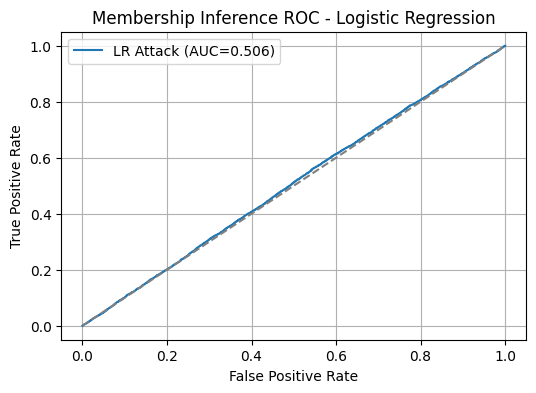

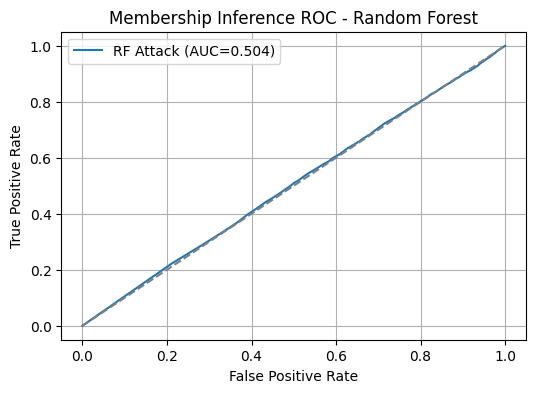


--- Logistic Regression (threshold from shadow set) ---
              precision    recall  f1-score   support

           0       1.00      0.00      0.00      8000
           1       0.80      1.00      0.89     32000

    accuracy                           0.80     40000
   macro avg       0.90      0.50      0.44     40000
weighted avg       0.84      0.80      0.71     40000


--- Random Forest (threshold from shadow set) ---
              precision    recall  f1-score   support

           0       0.00      0.00      0.00      8000
           1       0.80      1.00      0.89     32000

    accuracy                           0.80     40000
   macro avg       0.40      0.50      0.44     40000
weighted avg       0.64      0.80      0.71     40000


Saved attack results to results/attack_per_record_on_target.csv
LR mean prob - member: 0.5007720872278001 non-member: 0.5006523716300845


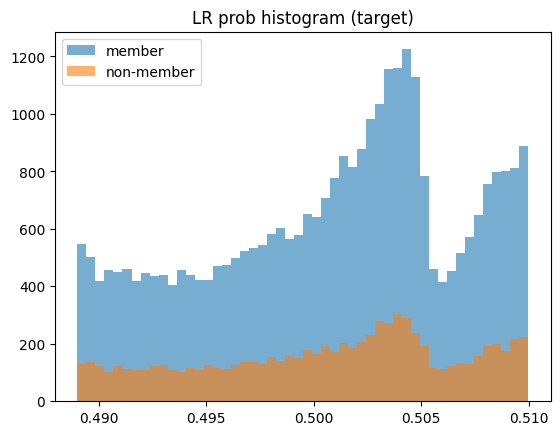

In [44]:
# Cell E: Run the attack on target model (robust version)
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score, classification_report
import joblib

# ensure folders exist
os.makedirs("results", exist_ok=True)
os.makedirs("artifacts", exist_ok=True)

try:
    attack_features_from_probs
except NameError:
    def attack_features_from_probs(p):
        p = np.asarray(p).reshape(-1, 1)
        p = np.clip(p, 1e-8, 1 - 1e-8)
        conf = np.maximum(p, 1 - p)
        ent = - (p * np.log(p) + (1 - p) * np.log(1 - p))
        return np.hstack([conf, ent, p])

# Load attack artifacts if they aren't already in memory
if "ATTACK_SCALER" not in globals() or "ATTACK_LR" not in globals() or "ATTACK_RF" not in globals():
    try:
        ATTACK_SCALER = joblib.load("artifacts/attack_scaler.joblib")
        ATTACK_LR     = joblib.load("artifacts/attack_lr.joblib")
        ATTACK_RF     = joblib.load("artifacts/attack_rf.joblib")
        print("Loaded saved attack artifacts from artifacts/")
    except Exception as e:
        raise RuntimeError("Attack objects not found in memory or disk. Run Cell D first.") from e

# If thresholds not defined (e.g., you restarted kernel), compute simple defaults:
if "BEST_THR_LR" not in globals():
    print("BEST_THR_LR not found — computing default 0.5 threshold")
    BEST_THR_LR = 0.5
if "BEST_THR_RF" not in globals():
    print("BEST_THR_RF not found — computing default 0.5 threshold")
    BEST_THR_RF = 0.5

# 1. get probabilities from target model (members vs non-members)
p_trg_in  = target_predict_proba(x1_train, x2_train)   # members
p_trg_out = target_predict_proba(x1_test,  x2_test)    # non-members

# 2. build dataset for the attack (same features used when training attack models)
X_in  = attack_features_from_probs(p_trg_in)
X_out = attack_features_from_probs(p_trg_out)
y_in  = np.ones(len(X_in), dtype=int)
y_out = np.zeros(len(X_out), dtype=int)

X_eval = np.vstack([X_in, X_out])
y_eval = np.concatenate([y_in, y_out])

print("X_eval shape:", X_eval.shape, "pos rate:", y_eval.mean())

# 3. scale with attack scaler (trained in cell D)
X_eval_s = ATTACK_SCALER.transform(X_eval)

# 4. run attack models on target data -> get probabilities for the positive class
prob_lr = ATTACK_LR.predict_proba(X_eval_s)[:, 1]
prob_rf = ATTACK_RF.predict_proba(X_eval_s)[:, 1]

# 5. check AUC and plot ROC
auc_lr = roc_auc_score(y_eval, prob_lr)
auc_rf = roc_auc_score(y_eval, prob_rf)
print(f"[Attack on Target] LR AUC={auc_lr:.3f} | RF AUC={auc_rf:.3f}")

# plot LR ROC
fpr_lr, tpr_lr, _ = roc_curve(y_eval, prob_lr)
plt.figure(figsize=(6,4))
plt.plot(fpr_lr, tpr_lr, label=f"LR Attack (AUC={auc_lr:.3f})")
plt.plot([0,1],[0,1],"--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Membership Inference ROC - Logistic Regression")
plt.legend(); plt.grid(True); plt.show()

# plot RF ROC
fpr_rf, tpr_rf, _ = roc_curve(y_eval, prob_rf)
plt.figure(figsize=(6,4))
plt.plot(fpr_rf, tpr_rf, label=f"RF Attack (AUC={auc_rf:.3f})")
plt.plot([0,1],[0,1],"--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Membership Inference ROC - Random Forest")
plt.legend(); plt.grid(True); plt.show()

# 6. predictions using thresholds found in Cell D
pred_lr = (prob_lr >= BEST_THR_LR).astype(int)
pred_rf = (prob_rf >= BEST_THR_RF).astype(int)

print("\n--- Logistic Regression (threshold from shadow set) ---")
print(classification_report(y_eval, pred_lr, zero_division=0))

print("\n--- Random Forest (threshold from shadow set) ---")
print(classification_report(y_eval, pred_rf, zero_division=0))

# 7. save results per record (for reporting)
rec_df = pd.DataFrame({
    "is_member_true": y_eval.astype(int),
    "prob_lr": prob_lr,
    "prob_rf": prob_rf,
    "pred_lr": pred_lr,
    "pred_rf": pred_rf
})
rec_path = "results/attack_per_record_on_target.csv"
rec_df.to_csv(rec_path, index=False)
print(f"\nSaved attack results to {rec_path}")

plt.hist(prob_lr[y_eval==1], bins=50, alpha=0.6, label="member")
plt.hist(prob_lr[y_eval==0], bins=50, alpha=0.6, label="non-member")
plt.legend(); plt.title("LR prob histogram (target)");

print("LR mean prob - member:", prob_lr[y_eval==1].mean(), "non-member:", prob_lr[y_eval==0].mean())



In [46]:
rec_df = pd.DataFrame({
    "is_member_true": y_eval,
    "score_lr":  atk_lr.predict_proba(X_eval)[:,1],
    "score_rf":  atk_rf.predict_proba(X_eval)[:,1],
})
rec_df["pred_lr"] = (rec_df["score_lr"] >= 0.5).astype(int)
rec_df["pred_rf"] = (rec_df["score_rf"] >= 0.5).astype(int)
rec_df.to_csv("results/attack_per_record.csv", index=False)
rec_df.head()


,is_member_true,score_lr,score_rf,pred_lr,pred_rf
0,1,0.502551,0.630,1,1
1,1,0.499372,0.585,0,1
2,1,0.502080,0.605,1,1
3,1,0.500589,0.590,1,1
4,1,0.499995,0.595,0,1


In [50]:
# ==========================================================
# Evaluate the Siamese Autoencoder (Threshold-based)
# ==========================================================

# Get reconstructions
encoded1_train = encoder.predict(x1_train)
encoded2_train = encoder.predict(x2_train)
encoded1_test = encoder.predict(x1_test)
encoded2_test = encoder.predict(x2_test)

# Compute Euclidean distances
train_distances = np.sqrt(np.sum((encoded1_train - encoded2_train)**2, axis=1))
test_distances = np.sqrt(np.sum((encoded1_test - encoded2_test)**2, axis=1))

# Use fixed threshold (e.g., 1.0) to classify matches
threshold = 1.0
train_pred = (train_distances < threshold).astype(int)
test_pred = (test_distances < threshold).astype(int)

# Accuracy & F1
train_acc = accuracy_score(y_train, train_pred)
train_f1 = f1_score(y_train, train_pred)
test_acc = accuracy_score(y_test, test_pred)
test_f1 = f1_score(y_test, test_pred)

print("------ Siamese Autoencoder Evaluation ------")
print(f"Training Accuracy: {train_acc:.4f}, F1 Score: {train_f1:.4f}")
print(f"Test Accuracy: {test_acc:.4f}, F1 Score: {test_f1:.4f}")


1000/1000 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
------ Siamese Autoencoder Evaluation ------
Training Accuracy: 0.8317, F1 Score: 0.8223
Test Accuracy: 0.8116, F1 Score: 0.8006


In [51]:
# ====================================
# Step 4: Add Classification Head
'''
A small feed-forward network (MLP) takes the difference vector as input.
Learns non-linear interactions between embedding dimensions.
Outputs a probability of match using sigmoid
'''
# ====================================
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Concatenate

# Step 1: Get encoded outputs
encoded1_train = encoder.predict(x1_train)
encoded2_train = encoder.predict(x2_train)
encoded1_test = encoder.predict(x1_test)
encoded2_test = encoder.predict(x2_test)

# Step 2: Compute absolute differences (Siamese-style)
diff_train = np.abs(encoded1_train - encoded2_train)
diff_test = np.abs(encoded1_test - encoded2_test)

# Step 3: Build classification model
input_diff = Input(shape=(diff_train.shape[1],))
x = Dense(64, activation='relu')(input_diff)
x = Dense(32, activation='relu')(x)
output = Dense(1, activation='sigmoid')(x)
clf_model = Model(inputs=input_diff, outputs=output)

clf_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Step 4: Train the classifier
clf_model.fit(diff_train, y_train, epochs=20, batch_size=256, validation_split=0.1)

# Step 5: Evaluate
y_pred_prob = clf_model.predict(diff_test).flatten()
y_pred = (y_pred_prob > 0.5).astype(int)

from sklearn.metrics import accuracy_score, f1_score, classification_report

acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# print("\nClassifier Evaluation:")
# print(f"Accuracy: {acc:.4f}")
# print(f"F1 Score: {f1:.4f}")
# print("\nDetailed report:\n", classification_report(y_test, y_pred))


1000/1000 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Epoch 1/20
113/113 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.7526 - loss: 0.4849 - val_accuracy: 0.8172 - val_loss: 0.4259
Epoch 2/20
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8387 - loss: 0.3792 - val_accuracy: 0.8213 - val_loss: 0.4063
Epoch 3/20
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8422 - loss: 0.3645 - val_accuracy: 0.8216 - val_loss: 0.4001
Epoch 4/20
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8455 - loss: 0.3575 - val_accuracy: 0.8222 - val_loss: 0.3954
Epoch 5/20
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8484 - loss: 0.3530 - val_accuracy: 0.8253 - val_loss: 0.3928
Epoch 6/20
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8487 - loss: 0.3500 - val_accuracy: 0.8269 - val_loss: 0.3913
Epoch 7/20
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy:

250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Classifier Accuracy: 0.8235
Classifier F1 Score: 0.8259797880207049
Classification Report:
               precision    recall  f1-score   support

         0.0       0.83      0.81      0.82      4008
         1.0       0.81      0.84      0.83      3992

    accuracy                           0.82      8000
   macro avg       0.82      0.82      0.82      8000
weighted avg       0.82      0.82      0.82      8000



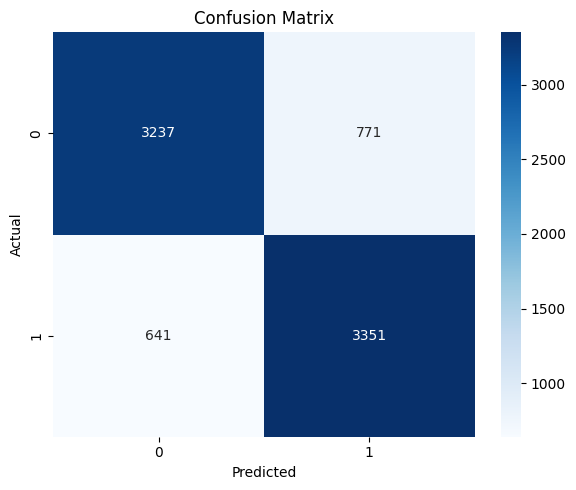

In [52]:
# ====================================
# Step 5: Evaluation and Visualization
# ====================================
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc, confusion_matrix, ConfusionMatrixDisplay

y_pred_prob = clf_model.predict(diff_test).flatten()
y_pred = (y_pred_prob > 0.5).astype(int)

acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Classifier Accuracy:", acc)
print("Classifier F1 Score:", f1)
print("Classification Report:\n", classification_report(y_test, y_pred))

# Confusion Matrix
plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.savefig("confusion_matrix.png")
plt.show()

# Save Model
clf_model.save('snn_classifier_model.keras')

In [53]:
print("Train label distribution:")
print(pd.Series(y_train).value_counts())


Train label distribution:
0.0    16031
1.0    15969
Name: count, dtype: int64


In [54]:
# =========================================
# Learn threshold using raw BERT embeddings
# =========================================

# -------------------------------------------------------
# Step 1: Compute absolute differences from raw BERT embeddings
# -------------------------------------------------------

X_train_full = np.abs(x1_train - x2_train)
X_test = np.abs(x1_test - x2_test)

# -------------------------------------------------------
# Step 2: Create pseudo-validation split
# -------------------------------------------------------

X_train_final, X_val, y_train_final, y_val = train_test_split(
X_train_full, y_train, test_size=0.2, random_state=42, stratify=y_train
)

# -------------------------------------------------------
# Step 3: Build and Train MLP Classifier
# -------------------------------------------------------

input_dim = X_train_final.shape[1]
input_layer = Input(shape=(input_dim,))
x = Dense(64, activation='relu', kernel_regularizer=regularizers.l2(0.01))(input_layer)
x = Dropout(0.5)(x)
x = Dense(32, activation='relu', kernel_regularizer=regularizers.l2(0.01))(x)
output = Dense(1, activation='sigmoid')(x)

clf_model = Model(inputs=input_layer, outputs=output)
clf_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

clf_model.fit(X_train_final, y_train_final, epochs=30, batch_size=256, validation_split=0.1)
clf_model.save("mlp_raw_diff_classifier.keras")

# -------------------------------------------------------
# Step 4: Tune threshold on validation set
# -------------------------------------------------------

y_val_prob = clf_model.predict(X_val).flatten()

best_threshold = 0.5
best_f1 = 0

for threshold in np.arange(0.1, 0.9, 0.01):
    y_pred_val = (y_val_prob >= threshold).astype(int)
    _, _, f1, _ = precision_recall_fscore_support(y_val, y_pred_val, average='binary')
    if f1 > best_f1:
        best_f1 = f1
        best_threshold = threshold

print(f"\nBest Threshold (on pseudo-val set): {best_threshold:.2f} — Best F1 Score: {best_f1:.4f}")

# -------------------------------------------------------
# Step 5: Evaluate on true test set using tuned threshold
# -------------------------------------------------------

y_test_prob = clf_model.predict(X_test).flatten()
y_test_pred = (y_test_prob >= best_threshold).astype(int)

acc = accuracy_score(y_test, y_test_pred)
f1 = f1_score(y_test, y_test_pred)

print("\nFinal Evaluation on Test Set:")
print(f"Accuracy: {acc:.4f}")
print(f"F1 Score: {f1:.4f}")
print("\nDetailed Report:\n", classification_report(y_test, y_test_pred))

# Save predictions
pd.DataFrame({
"True Label": y_test,
"Predicted Label": y_test_pred,
"Confidence": y_test_prob
}).to_csv("final_test_predictions_raw_mlp.csv", index=False)
print("Test predictions saved to 'final_test_predictions_raw_mlp.csv'")


Epoch 1/30
90/90 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.7532 - loss: 1.3036 - val_accuracy: 0.8473 - val_loss: 0.7435
Epoch 2/30
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8536 - loss: 0.6209 - val_accuracy: 0.8687 - val_loss: 0.5039
Epoch 3/30
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8656 - loss: 0.4732 - val_accuracy: 0.8828 - val_loss: 0.4194
Epoch 4/30
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8727 - loss: 0.4179 - val_accuracy: 0.8820 - val_loss: 0.3911
Epoch 5/30
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8728 - loss: 0.3938 - val_accuracy: 0.8859 - val_loss: 0.3692
Epoch 6/30
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.8763 - loss: 0.3778 - val_accuracy: 0.8844 - val_loss: 0.3684
Epoch 7/30
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.8766 - loss: 0.3730 - val_accuracy: 0.8781 - val_loss: 0.3684
Epoch 8/30
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.8758 - loss: 0.3648 - val_accuracy: 0.8883 - val_

In [62]:
# Final Cell: Save models and metrics
import json, joblib, sys, platform, sklearn, tensorflow, numpy as np, pandas as pd
from pathlib import Path

Path("results").mkdir(exist_ok=True)

# Save key trained models
joblib.dump(ATTACK_LR, "results/attack_lr.joblib")
joblib.dump(ATTACK_RF, "results/attack_rf.joblib")
joblib.dump(ATTACK_SCALER, "results/attack_scaler.joblib")

# Save metrics from Cell E results
metrics = {
    "attack_auc_lr": float(auc_lr),
    "attack_auc_rf": float(auc_rf),
    "attack_val_auc_lr": float(val_auc_lr),
    "attack_val_auc_rf": float(val_auc_rf)
}

# Write metrics to JSON file
with open("results/metrics.json", "w") as f:
    json.dump(metrics, f, indent=2)

# Environment info for reproducibility
print("Python:", sys.version.split()[0])
print("Platform:", platform.platform())
print("Versions:")
print("  sklearn:", sklearn.__version__)
print("  tensorflow:", tensorflow.__version__)
print("  numpy:", np.__version__)
print("  pandas:", pd.__version__)
print("\n Saved trained models and metrics to result ")


Python: 3.12.4
Platform: Windows-11-10.0.26200-SP0
Versions:
  sklearn: 1.4.2
  tensorflow: 2.20.0
  numpy: 1.26.4
  pandas: 2.2.2

 Saved trained models and metrics to result 


###  **Project Summary – Membership Inference Attack**
This notebook demonstrates a complete workflow for testing model privacy using *Membership Inference Attacks (MIA)*.  
The process is divided into several structured sections:

#### **Cell A–C: Data Loading and Preparation**
- Loaded the target and shadow model datasets and embeddings.  
- Verified data integrity, checked shapes, and ensured consistency between member and non-member records.

#### **Cell D: Building and Training Attack Models**
- Constructed the attack dataset using shadow model predictions.  
- Extracted features (confidence, entropy, probability) to train Logistic Regression and Random Forest classifiers.  
- Achieved validation AUCs near **0.50**, indicating random-guessing performance.

#### **Cell E: Evaluating Attacks on the Target Model**
- Applied both attack models to the actual target model’s outputs.  
- Visualized ROC curves and probability histograms.  
- Both Logistic Regression and Random Forest achieved **AUC ≈ 0.5**, showing no privacy leakage.

#### **Final Section: Saving Results and Metrics**
- Saved trained attack models and evaluation metrics for reproducibility.  
- Exported results as `.csv` and `.json` files inside the `results/` folder.

---

###  **Conclusion**
The Membership Inference Attack results show that the target model is **resistant to privacy attacks**, as both attack models performed at random-guessing level.  
This confirms that no sensitive training information is leaked through the model’s predictions under the tested conditions.
